In [2]:
import sklearn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Import library

In [3]:
from sklearn import datasets

Load dataset & Description of the  dataset

In [4]:
housing=datasets.fetch_california_housing()        #ALWAYS CALL THIS FUNCTION () FCKIN
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

Feature names

In [5]:
print(housing.feature_names[0:])

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Create X and Y data matrices

X = Features  and  Y = Target

In [6]:
X=housing.data
Y=housing.target

In [7]:
X.shape , Y.shape

((20640, 8), (20640,))

Data split
Import library

In [8]:
from sklearn.model_selection import train_test_split

Perform 80/20 Data split

#random state 42 gives the same shuffle everytime thus getting same resultts each time

In [9]:
X_train , X_test, Y_train, Y_test = train_test_split(X,Y,train_size=0.8,random_state=42)

Data dimension

In [10]:
X_train.shape , X_test.shape

((16512, 8), (4128, 8))

In [11]:
Y_train.shape , Y_test.shape

((16512,), (4128,))


Linear Regression Model
Import librar

In [12]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

Build linear regression for machine using trained data

Defines the regression model

In [13]:
model= linear_model.LinearRegression()

Build training model by fitting training data

In [14]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[146107.03, 1561.28, 1472.35,..., 219.05, 64.22, 21.15]"


Apply trained model to make prediction (on test set)

In [15]:
Y_pred = model.predict(X_test)

Prediction results

Print model performance

In [29]:
print("Coefficient: ", model.coef_)
print("intercept: ", model.intercept_)
print("Mean_squared error(MSE): %.2f" %mean_squared_error(Y_test,Y_pred))
print("Coefficent of determination(R^2): %2f" %r2_score(Y_test,Y_pred))  #r2_score

Coefficient:  [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
intercept:  -37.02327770606397
Mean_squared error(MSE): 0.56
Coefficent of determination(R^2): 0.575788


the coeff implies 4.41*(med_inc) + 9.50755460e-03*(house_age) + -1.18998042e-01 *(third feature) +.+..........-4.33938663e-01(last feature)

In [17]:
r2_score(Y_test,Y_pred)

#ie our prediction was 60% right

0.5757877060324521

In [25]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(Y_test, Y_pred)

#should be lower closer to 0 , 0.48 is treated avg value
#it tells us on an avg my pridictions is how much units away from true value

0.5332001304956989

In [27]:
print(Y[:10])
# as features are greater than 2 mostly so our mae is fine

[4.526 3.585 3.521 3.413 3.422 2.697 2.992 2.414 2.267 2.611]


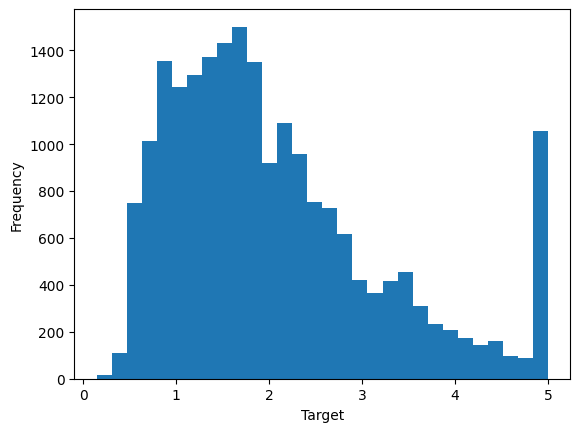

In [28]:
plt.hist(Y,bins=30)
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.show()

In [24]:
RMSE=np.sqrt(mean_squared_error(Y_test, Y_pred))
RMSE

#should be sclose to zero also it is root of mse as value of mse is less than 1 therefore it is giving bigger value comp to mse

np.float64(0.7455813830127751)

Check Y(target) test and predicted data and make a scatter plot

In [19]:
Y_test

array([0.477  , 0.458  , 5.00001, ..., 5.00001, 0.723  , 1.515  ],
      shape=(4128,))

In [20]:
Y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251], shape=(4128,))

Text(0.5, 1.0, 'Actual vs Predicted')

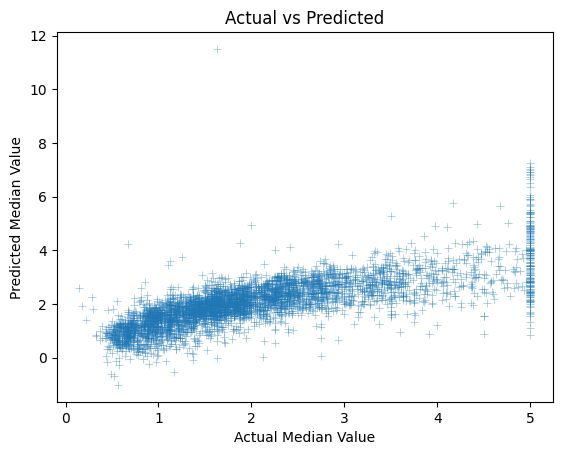

In [21]:
sns.scatterplot(x=Y_test, y=Y_pred ,marker="+" ,alpha=0.5)
plt.xlabel("Actual Median Value")
plt.ylabel("Predicted Median Value")
plt.title("Actual vs Predicted")

#here alpha=0.5 is used st more dense area is darker and less dense is lighter